# **DATA MODELLING**

## UNSUPERVISED LEARNING - Clustering

Lets look at a very simple example of unsupervised learning.

###1. Load and Explore the data

1.1 Load the penguis dataset from seaborn.

In [ ]:
# imports
import seaborn as sns

# Load the dataset
df = sns.load_dataset("penguins")

1.2 Look at the raw data.

In [ ]:
# Display head of the data
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


1.3 Visualise the data using a [3D scatter plot](https://matplotlib.org/stable/gallery/mplot3d/scatter3d.html).
Select three suitable variables to plot.

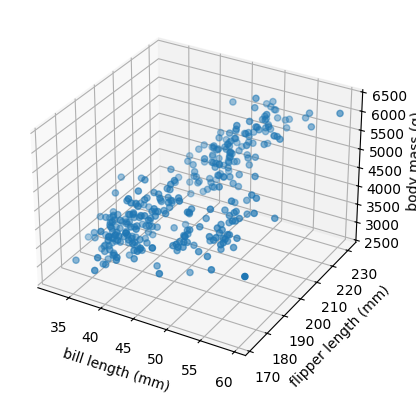

In [ ]:
#Import the relevant libraries
import matplotlib.pyplot as plt

# Visualisation code here
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df['bill_length_mm'], df['flipper_length_mm'], df['body_mass_g'])
ax.set_xlabel('bill length (mm)')
ax.set_ylabel('flipper length (mm)')
ax.set_zlabel('body mass (g)')
plt.show()

###2. Data Processing - part 1

2.1 Identify the catagorical columns (https://medium.com/@fathima.nusra.thameem/how-to-find-categorical-columns-in-your-pandas-dataframe-e7553feef62e) and put them in a list.

Hint: look for 'catagory' AND 'object'.

In [ ]:
cat_cols = list(df.select_dtypes(include=['object', 'category']).columns)
print(cat_cols)

['species', 'island', 'sex']


2.2 Encode categorical variables 'island', 'species' and 'sex' using [LabelEncoder](https://www.geeksforgeeks.org/machine-learning/ml-label-encoding-of-datasets-in-python/).

In [ ]:
# Encode categorical variables.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['species'].unique())
df['species'] = le.transform(df['species'])
le.fit(df['island'].unique())
df['island'] = le.transform(df['island'])
le.fit(df['sex'].unique())
df['sex'] = le.transform(df['sex'])
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,1
1,0,2,39.5,17.4,186.0,3800.0,0
2,0,2,40.3,18.0,195.0,3250.0,0
3,0,2,NaN,NaN,NaN,NaN,2
4,0,2,36.7,19.3,193.0,3450.0,0


###3. Exploratory Data Analysis
Here we have a simple dataset, but what would you do if it was more complicated? EDA!

Let's use pairplots and 3D scatter plots to do some EDA...

3.1 Lets start with the seaborn [Pair plot](https://seaborn.pydata.org/generated/seaborn.pairplot.html).

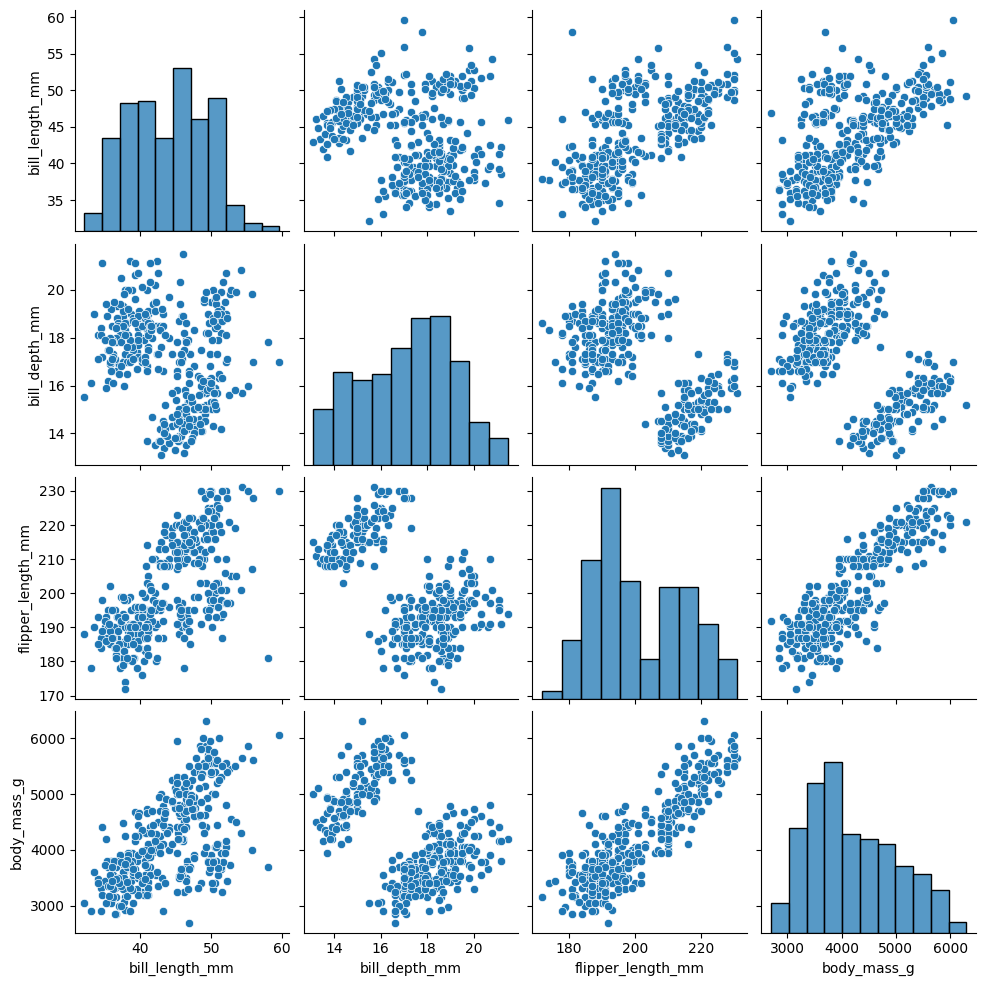

In [ ]:
sns.pairplot(df[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]])

3.2 Let's recreate the earlier [3D scatter plot](https://machinelearningmastery.com/data-visualization-in-python-with-matplotlib-seaborn-and-bokeh/) but add the species as the hue (c).

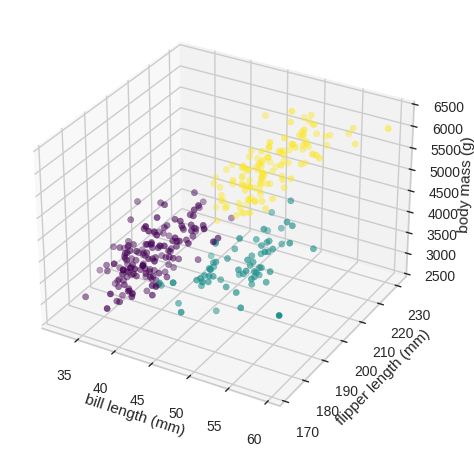

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df['bill_length_mm'], df['flipper_length_mm'], df['body_mass_g'], c=df["species"], cmap='viridis')
ax.set_xlabel('bill length (mm)')
ax.set_ylabel('flipper length (mm)')
ax.set_zlabel('body mass (g)')
plt.show()

### 4.  Data Processing - part 2

4.1 Remove the catagorical columns - It makes no sense to do clustering if we include the catagorical data. Let's see if we will still have the expected 3 clusters without it.

4.2 Remove the records with missing nans,

4.3 randomise the data and

4.4 standardise the data.

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
df_cleaned = df.drop(cat_cols, axis=1) ## sd.drop(['species','island','sex'], axis=1)
df_cleaned = df_cleaned.dropna()
df_cleaned = df_cleaned.sample(frac=1)
scaler = MinMaxScaler()
df_cleaned = scaler.fit_transform(df_cleaned) ## note that the standardisation function converts the dataframe to a numpy array.

### 5. Clustering
Clearly clustering would be an ideal solution, so lets try the K=means method.

Look at the documentation for the **python library "sklearn kmeans clustering"** for what the algorithm requires.

From the documentation the only input the algorithm requires is the number of clusters (k).
It should be noted that while a random state is not required, it would be a good idea to set it for reproducablilty, we can just choose 0.

5.1 Determine number of clusters.

The way to determine the optimal number of clusters is to use the **elbow method**. More information on how to impliment this method can be obtained by looking at the documentation for the elbow method in the python library yellowbrick by searching something like **"yellowbrick elbow method"**.

Follow the instructions and impliment the elbow method to determine the optimal number of clusters.

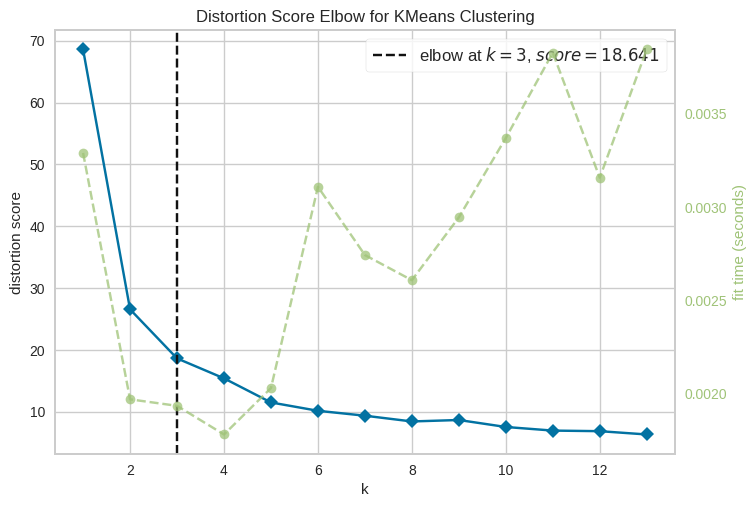

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,14))
visualizer.fit(df_cleaned)
visualizer.show()

Determine where the elbow 'bends' (blue line) to the largest degree or the most obviously.

NOTE: if the data in not suitable for clustering, the method wont work well or even at all.

5.2 Run the model.

Next, we implement the kmeans clusterning using the instructions in the sklearn kmeans documentation and fit the model to the data. (Because it's unsupervised ther is no train/test split or target varaible).

In [ ]:
kmeans = KMeans(n_clusters=3).fit(df_cleaned)

5.3 Display the predicted cluster centers.

Lest see where the identified cluster centers are located using a print statement.

In [ ]:
centroids = kmeans.cluster_centers_
print(centroids)

[[0.54253746 0.68772894 0.42689514 0.34668803]
 [0.56017738 0.22406117 0.76588122 0.66000452]
 [0.22460227 0.5843564  0.2699947  0.23388672]]


5.4 Visualising cluster centers on data.

Finally lets visualise the previous 3D plot, but now also include the cluster centers on the plot.

But remember, we standardised the data, so you either need to plot the 3D plot using df_cleaned with the centroids OR transform the centroids to the original value sizes and use the previous plots.

Use the MinMaxScaler object that you created previously with "inverse_transform" to transform the centroids.

In [ ]:
centroids_inv = scaler.inverse_transform(centroids)
print(centroids_inv)

[[  47.01978022   18.87692308  197.18681319 3948.07692308]
 [  47.50487805   14.98211382  217.18699187 5076.01626016]
 [  38.2765625    18.00859375  187.9296875  3541.9921875 ]]


Now let's visualise. (**HINT**: use a scatterplot with markers and count in what columns the features that you are plotting are. E.g body_mass was in column 3.)

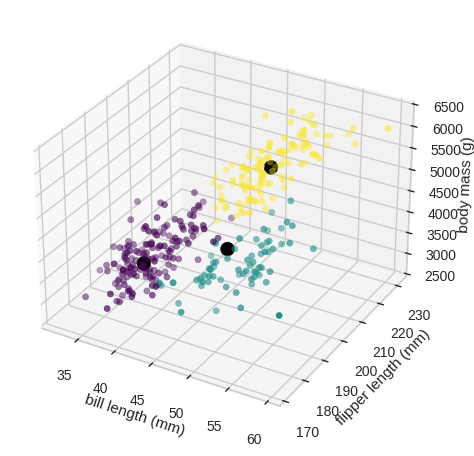

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df['bill_length_mm'], df['flipper_length_mm'], df['body_mass_g'], c=df["species"], cmap='viridis')
## plot centroids
ax.scatter(centroids_inv[:,0],centroids_inv[:,2],centroids_inv[:,3],c="black",s=100,label="Centers",alpha=1)
ax.set_xlabel('bill length (mm)')
ax.set_ylabel('flipper length (mm)')
ax.set_zlabel('body mass (g)')
plt.show()